<a href="https://colab.research.google.com/github/chitrasavithri176-cmyk/python-ex/blob/main/OIBSIP_DATA_SCIENCE_Task_1_Unemployment_in_India.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


df = pd.read_csv("Unemployment in India.csv")

print("Original columns:", df.columns.tolist())

df.columns = df.columns.str.strip()


print("Stripped columns:", df.columns.tolist())


df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


df.dropna(inplace=True)


df.head()

Original columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']
Stripped columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
print(f"Shape of the DataFrame after cleaning: {df.shape}")

Shape of the DataFrame after cleaning: (740, 7)


In [ ]:
print("\nNull values in each column after cleaning:")
display(df.isnull().sum())


Null values in each column after cleaning:


,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [ ]:
print("\nData types of columns after cleaning:")
display(df.info())


Data types of columns after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


None

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

region_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

print("Average Unemployment Rate (%) by Region:\n")
print(region_unemployment.round(2))

Average Unemployment Rate (%) by Region:

Region
Tripura             28.35
Haryana             26.28
Jharkhand           20.58
Bihar               18.92
Himachal Pradesh    18.54
Delhi               16.50
Jammu & Kashmir     16.19
Chandigarh          15.99
Rajasthan           14.06
Uttar Pradesh       12.55
Punjab              12.03
Puducherry          10.22
Kerala              10.12
Tamil Nadu           9.28
Goa                  9.27
Chhattisgarh         9.24
West Bengal          8.12
Telangana            7.74
Maharashtra          7.56
Andhra Pradesh       7.48
Madhya Pradesh       7.41
Sikkim               7.25
Karnataka            6.68
Gujarat              6.66
Uttarakhand          6.58
Assam                6.43
Odisha               5.66
Meghalaya            4.80
Name: Estimated Unemployment Rate (%), dtype: float64


/tmp/ipykernel_512/393713194.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_unemployment.values, y=region_unemployment.index, palette='viridis')


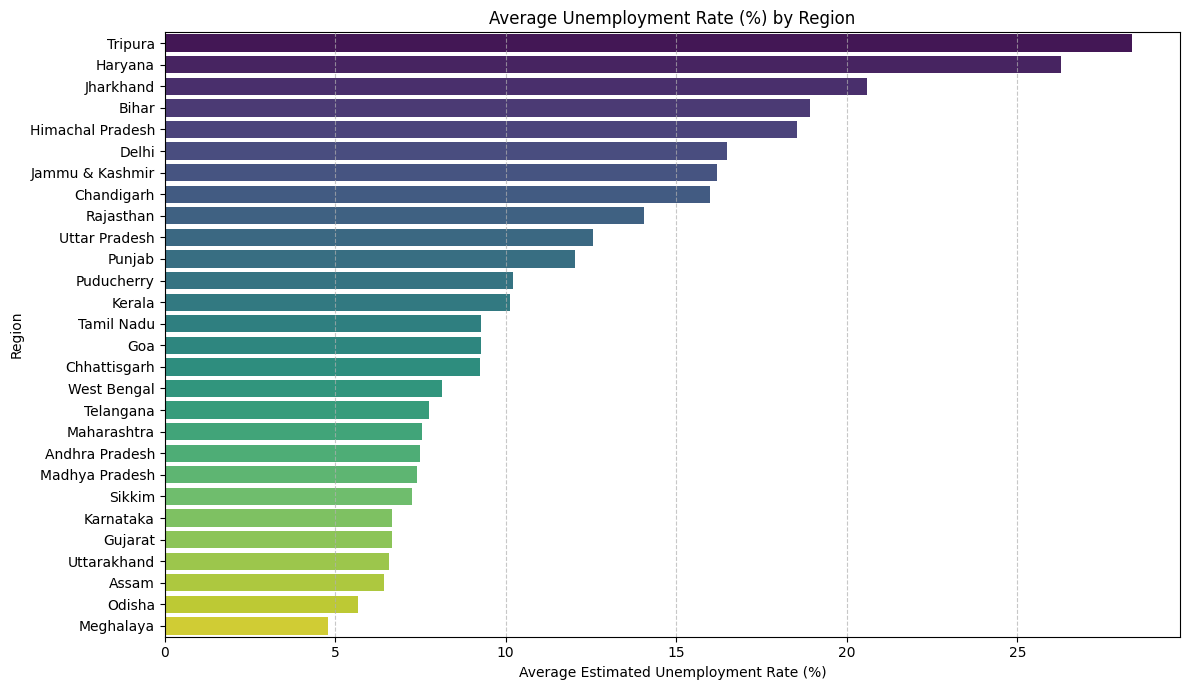

In [ ]:
fig = plt.figure(figsize=(12, 7))
sns.barplot(x=region_unemployment.values, y=region_unemployment.index, palette='viridis')
plt.title('Average Unemployment Rate (%) by Region')
plt.xlabel('Average Estimated Unemployment Rate (%)')
plt.ylabel('Region')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Region-wise Unemployment Rate Observations

The bar chart above displays the average estimated unemployment rate across different regions. It highlights significant disparities, with **Tripura (28.35%)**, **Haryana (26.28%)**, and **Jharkhand (20.58%)** consistently showing the highest average unemployment rates. This indicates regional variations in economic stability and job opportunities.

In [ ]:

df['Month'] = df['Date'].dt.month


month_mapping = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
    7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
df['Month_Name'] = df['Month'].map(month_mapping)


month_unemployment = df.groupby('Month_Name')['Estimated Unemployment Rate (%)'].mean().reindex(list(month_mapping.values()))

print("Average Unemployment Rate (%) by Month:\n")
print(month_unemployment.round(2))

Average Unemployment Rate (%) by Month:

Month_Name
January       9.95
February      9.96
March        10.70
April        23.64
May          16.65
June         10.55
July          9.03
August        9.64
September     9.05
October       9.90
November      9.87
December      9.50
Name: Estimated Unemployment Rate (%), dtype: float64


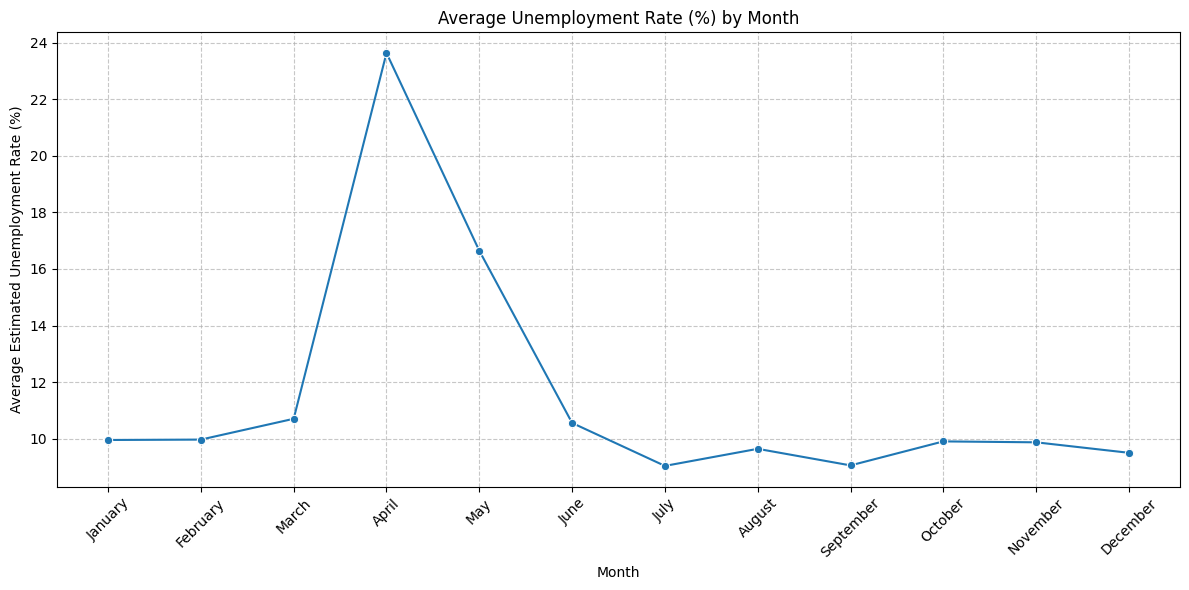

In [ ]:
fig = plt.figure(figsize=(12, 6))
sns.lineplot(x=month_unemployment.index, y=month_unemployment.values, marker='o')
plt.title('Average Unemployment Rate (%) by Month')
plt.xlabel('Month')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Month-wise Unemployment Rate Observations

The line plot illustrates the average estimated unemployment rate across different months. A striking observation is the significant surge in unemployment during **April (23.64%)** and **May (16.65%)**. This pattern likely reflects the impact of seasonal economic activities or specific events that occurred during these months, such as the initial phase of the COVID-19 pandemic in 2020 which heavily impacted these months.

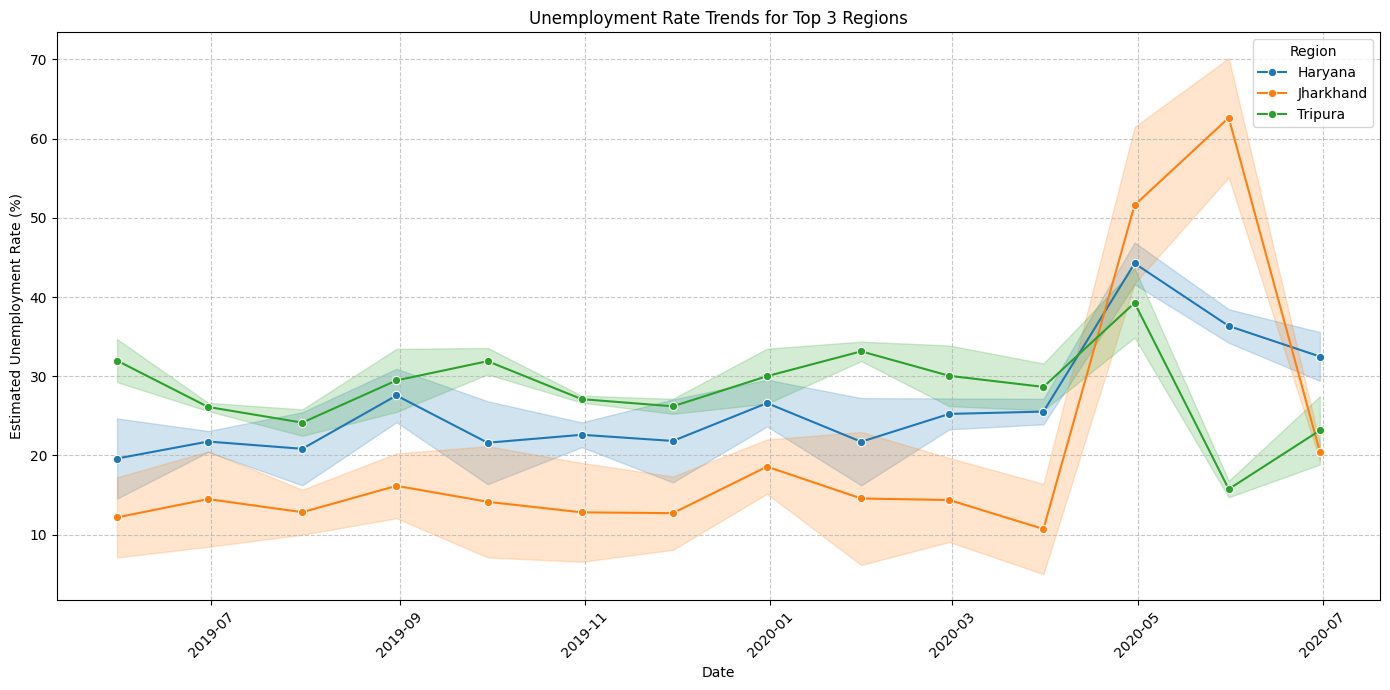

In [ ]:

top_regions = region_unemployment.head(3).index.tolist()


df_top_regions = df[df['Region'].isin(top_regions)]


fig = plt.figure(figsize=(14, 7))
sns.lineplot(data=df_top_regions, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', marker='o')

plt.title('Unemployment Rate Trends for Top 3 Regions')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

### Unemployment Rate Trends for Top 3 Regions Observations

This line plot visualizes the unemployment rate trends over time for the three regions with the highest average unemployment rates: Tripura, Haryana, and Jharkhand. All three regions show considerable fluctuation and volatility in their unemployment rates, with noticeable peaks and troughs over the period. This suggests that these regions are particularly vulnerable to economic shifts and may lack stable employment opportunities compared to other parts of the country.

/tmp/ipykernel_512/3673662927.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_regions.values, y=top_10_regions.index, palette='magma')


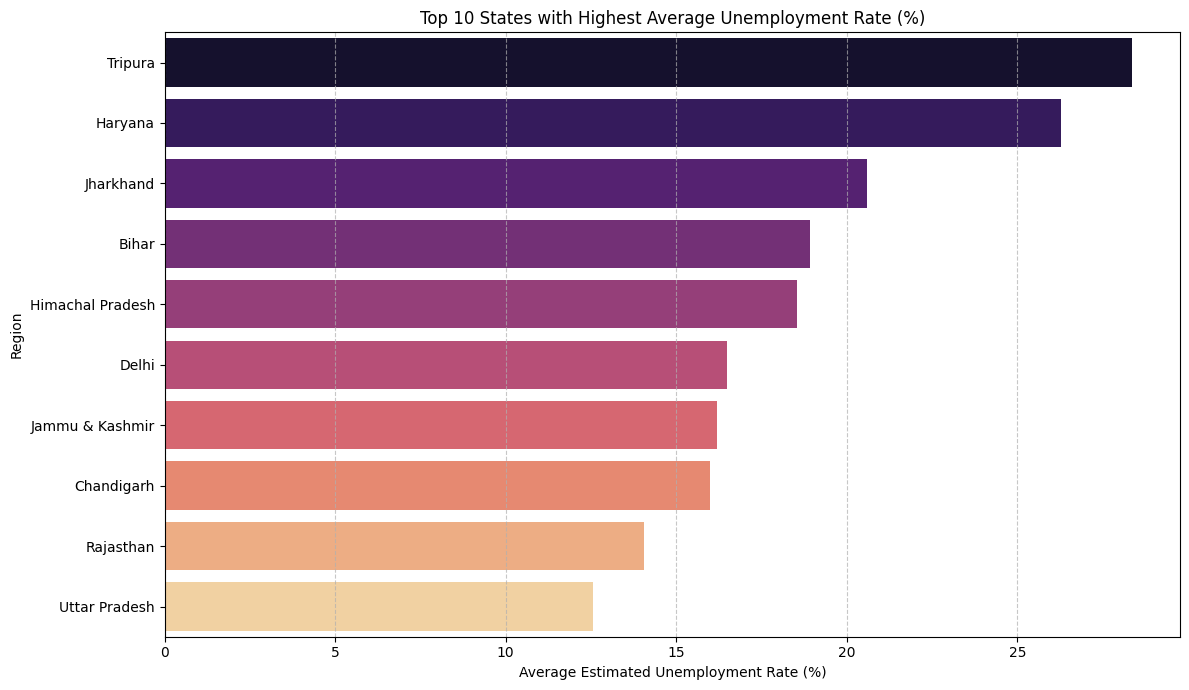

In [ ]:

top_10_regions = region_unemployment.head(10)


fig = plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_regions.values, y=top_10_regions.index, palette='magma')

plt.title('Top 10 States with Highest Average Unemployment Rate (%)')
plt.xlabel('Average Estimated Unemployment Rate (%)')
plt.ylabel('Region')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Top 10 States with Highest Average Unemployment Rate Observations

This bar chart reinforces the regional disparities seen earlier, specifically highlighting the top 10 states with the highest average unemployment rates. The states shown here consistently exhibit elevated unemployment compared to the national average, pointing towards structural challenges or economic distress in these specific regions.

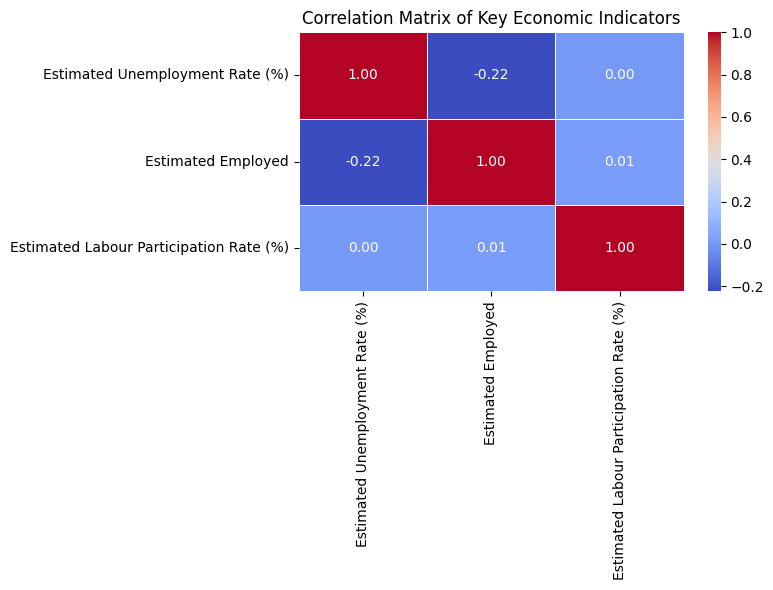

In [ ]:

correlation_data = df[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']]


correlation_matrix = correlation_data.corr()


fig = plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

plt.title('Correlation Matrix of Key Economic Indicators')
plt.tight_layout()
plt.show()

### Correlation Matrix Observations

The heatmap displays the correlation matrix between key economic indicators: 'Estimated Unemployment Rate (%)', 'Estimated Employed', and 'Estimated Labour Participation Rate (%)'.

*   There is a **weak negative correlation (-0.22)** between 'Estimated Unemployment Rate (%)' and 'Estimated Employed'. This is expected, as higher employment generally leads to lower unemployment, though the correlation isn't very strong in this dataset.
*   The correlations involving 'Estimated Labour Participation Rate (%)' are very weak (close to zero). This indicates that the labour participation rate, in this dataset, does not have a strong linear relationship with either unemployment or employment rates.

Average Unemployment Rate (Pre-COVID): 9.51%
Average Unemployment Rate (Post-COVID): 17.77%


/tmp/ipykernel_512/3355782690.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Period', y='Average Unemployment Rate (%)', data=comparison_df, palette=['skyblue', 'salmon'])


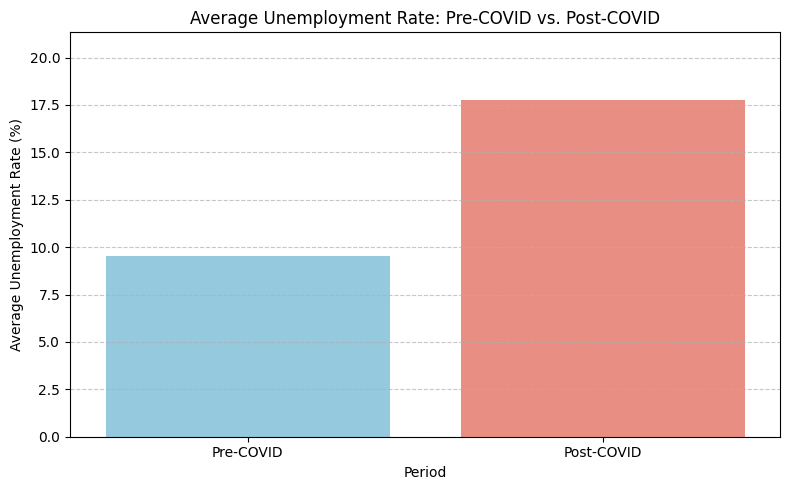

In [ ]:

covid_start_date = pd.to_datetime('2020-03-01')


pre_covid_df = df[df['Date'] < covid_start_date]
post_covid_df = df[df['Date'] >= covid_start_date]


mean_unemployment_pre_covid = pre_covid_df['Estimated Unemployment Rate (%)'].mean()
mean_unemployment_post_covid = post_covid_df['Estimated Unemployment Rate (%)'].mean()

print(f"Average Unemployment Rate (Pre-COVID): {mean_unemployment_pre_covid:.2f}%")
print(f"Average Unemployment Rate (Post-COVID): {mean_unemployment_post_covid:.2f}%")


comparison_df = pd.DataFrame({
    'Period': ['Pre-COVID', 'Post-COVID'],
    'Average Unemployment Rate (%)': [mean_unemployment_pre_covid, mean_unemployment_post_covid]
})

fig = plt.figure(figsize=(8, 5))
sns.barplot(x='Period', y='Average Unemployment Rate (%)', data=comparison_df, palette=['skyblue', 'salmon'])
plt.title('Average Unemployment Rate: Pre-COVID vs. Post-COVID')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')
plt.ylim(0, max(mean_unemployment_pre_covid, mean_unemployment_post_covid) * 1.2) # Set y-limit for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Pre-COVID vs. Post-COVID Unemployment Rate Observations

The bar chart vividly contrasts the average unemployment rates before and after the defined COVID-19 start date (March 2020). There is a significant increase in the average unemployment rate from **9.51% (Pre-COVID)** to **17.77% (Post-COVID)**. This nearly doubling of the unemployment rate underscores the severe economic impact of the COVID-19 pandemic on the job market, aligning with global and national economic trends observed during that period.

Average Unemployment Rate (%) by Area:
    Area  Estimated Unemployment Rate (%)
0  Rural                            10.32
1  Urban                            13.17


/tmp/ipykernel_512/610973659.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Area', y='Estimated Unemployment Rate (%)', data=urban_rural_unemployment, palette=['teal', 'purple'])


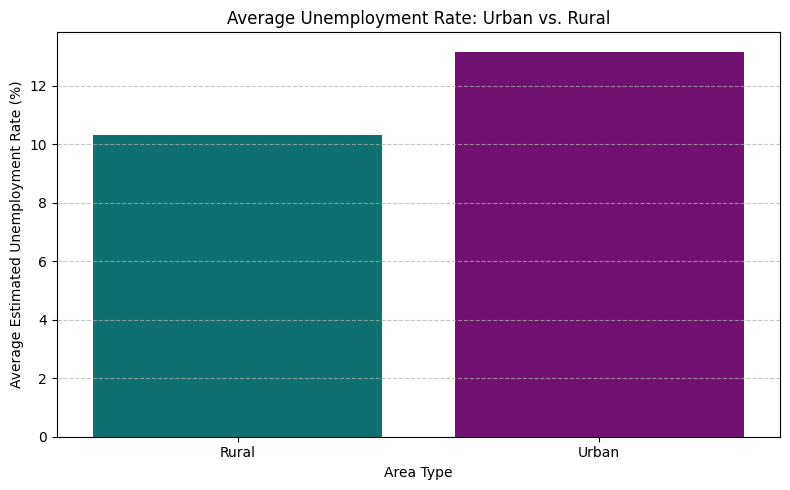

In [ ]:

urban_rural_unemployment = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean().reset_index()

print("Average Unemployment Rate (%) by Area:")
print(urban_rural_unemployment.round(2))


fig = plt.figure(figsize=(8, 5))
sns.barplot(x='Area', y='Estimated Unemployment Rate (%)', data=urban_rural_unemployment, palette=['teal', 'purple'])
plt.title('Average Unemployment Rate: Urban vs. Rural')
plt.xlabel('Area Type')
plt.ylabel('Average Estimated Unemployment Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Urban vs. Rural Unemployment Rate Observations

The bar chart illustrates a clear difference in unemployment rates between urban and rural areas. Urban regions exhibit a higher average estimated unemployment rate of **13.17%**, compared to rural areas which have an average rate of **10.32%**. This suggests that job availability or economic conditions might be more challenging in urban settings or that urban populations face different employment dynamics compared to their rural counterparts.

### Summary of Key Observations from the Unemployment Data Analysis

### 1. Data Cleaning and Initial Insights
*   The dataset initially contained some missing values and inconsistent column names. After cleaning, the DataFrame consists of 740 entries with no null values and correctly formatted 'Date' column.

### 2. Regional Disparities in Unemployment
*   **Region-wise Average Unemployment Rates**: Tripura (28.35%), Haryana (26.28%), and Jharkhand (20.58%) consistently show the highest average unemployment rates, indicating significant regional variations.
*   **Unemployment Rate Trends for Top 3 Regions**: These high-unemployment regions exhibit considerable fluctuation and volatility in their rates over time, suggesting vulnerability to economic shifts.
*   **Top 10 States**: The bar chart of the top 10 states reinforces these regional disparities, highlighting persistent challenges in certain areas.

### 3. Monthly and Seasonal Trends
*   **Month-wise Unemployment Trends**: A notable surge in unemployment was observed during April (23.64%) and May (16.65%), likely influenced by seasonal economic activities or significant events like the initial phase of the COVID-19 pandemic in 2020.

### 4. Impact of COVID-19
*   **Pre-COVID vs. Post-COVID Comparison**: There was a significant increase in the average unemployment rate from 9.51% (Pre-COVID, before March 2020) to 17.77% (Post-COVID), underscoring the severe economic impact of the pandemic on the job market.

### 5. Urban vs. Rural Differences
*   **Urban vs. Rural Unemployment Rate Comparison**: Urban areas exhibit a higher average estimated unemployment rate of 13.17%, compared to rural areas at 10.32%. This suggests different employment dynamics or challenges in urban settings.

### 6. Correlations Between Economic Indicators
*   **Correlation Matrix**: A weak negative correlation (-0.22) was found between 'Estimated Unemployment Rate (%)' and 'Estimated Employed'. The 'Estimated Labour Participation Rate (%)' showed very weak correlations with both unemployment and employment, indicating a limited linear relationship in this dataset.